# RandomForest Cirrhosis Optimized
Target: Cirrhosis_Status

In [13]:
!pip install -q xgboost

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading : nafld2.csv
Loading : nwtco.csv
Loading : nafld1.csv

Dataset shape:
(421700, 21)

Columns:
Index(['Unnamed: 0', 'id', 'days', 'test', 'value', 'seqno', 'instit',
       'histol', 'stage', 'study', 'rel', 'edrel', 'age', 'in.subcohort',
       'male', 'weight', 'height', 'bmi', 'case.id', 'futime', 'status'],
      dtype='object')

Target distribution:
status
0.0    420336
1.0      1364
Name: count, dtype: int64

Scale positive weight: 308.2208982584785

Training XGBoost...
Training finished

========== RESULTS ==========
Accuracy: 0.979191368271283
Precision: 0.12763819095477386
Recall: 0.9304029304029304
F1-score: 0.22448077772867875
ROC-AUC: 0.9930703275178515
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     84067
         1.0       0.13      0.93      0.22       273

    accuracy              

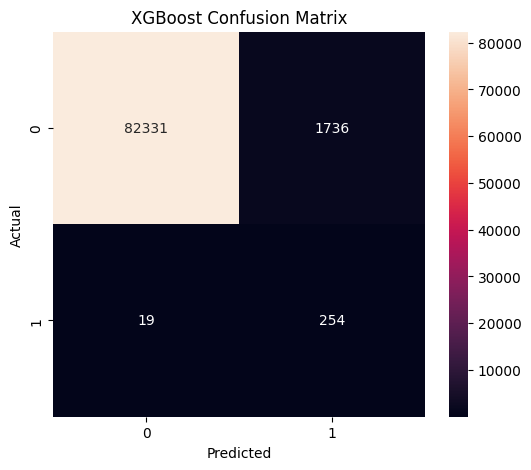


XGBoost MODEL SAVED
/content/drive/MyDrive/5/XGBoost_model


In [53]:
# =====================================================
# NAFLD - XGBOOST MODEL
# Google Colab + Google Drive
# =====================================================


from google.colab import drive
drive.mount('/content/drive')


import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib



# =====================================================
# PATH
# =====================================================


PROJECT_PATH = "/content/drive/MyDrive/5"


MODEL_PATH = PROJECT_PATH + "/XGBoost_model"


RESULT_PATH = PROJECT_PATH + "/XGBoost_results"


os.makedirs(
    MODEL_PATH,
    exist_ok=True
)


os.makedirs(
    RESULT_PATH,
    exist_ok=True
)



# =====================================================
# LOAD DATASETS FROM FOLDER
# =====================================================


datasets = []


for file in os.listdir(PROJECT_PATH):

    if file.endswith(".csv"):

        print("Loading :", file)


        df = pd.read_csv(
            os.path.join(
                PROJECT_PATH,
                file
            )
        )


        datasets.append(df)



# Merge datasets

data = pd.concat(
    datasets,
    ignore_index=True
)



print("\nDataset shape:")
print(data.shape)



print("\nColumns:")
print(data.columns)



# =====================================================
# CLEANING
# =====================================================


# supprimer colonne inutile

data.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
    inplace=True
)



# remplir valeurs manquantes

for col in data.columns:


    if data[col].dtype == "object" or data[col].dtype == "bool":


        data[col] = data[col].fillna(
            "Unknown"
        )


    else:


        data[col] = data[col].fillna(
            data[col].median()
        )



# =====================================================
# TARGET
# =====================================================


TARGET = "status"



X = data.drop(

    columns=[
        TARGET,
        "id",
        "case.id"
    ],

    errors="ignore"

)



y = data[TARGET]



print("\nTarget distribution:")

print(y.value_counts())



# =====================================================
# ENCODING
# =====================================================


encoders = {}



for col in X.columns:


    if X[col].dtype == "object" or X[col].dtype == "bool":


        X[col] = X[col].astype(str)


        encoder = LabelEncoder()


        X[col] = encoder.fit_transform(
            X[col]
        )


        encoders[col] = encoder



# =====================================================
# TRAIN TEST SPLIT
# =====================================================


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



# =====================================================
# HANDLE IMBALANCE
# =====================================================


negative = sum(y_train == 0)

positive = sum(y_train == 1)


scale_weight = negative / positive



print(
    "\nScale positive weight:",
    scale_weight
)



# =====================================================
# XGBOOST MODEL
# =====================================================


model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_weight,

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)



print("\nTraining XGBoost...")


model.fit(

    X_train,

    y_train

)


print("Training finished")



# =====================================================
# PREDICTION
# =====================================================


y_pred = model.predict(
    X_test
)


y_prob = model.predict_proba(
    X_test
)[:,1]



# =====================================================
# EVALUATION
# =====================================================


print("\n========== RESULTS ==========")


print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)


print(
    "F1-score:",
    f1_score(
        y_test,
        y_pred
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)



print(
    classification_report(
        y_test,
        y_pred
    )
)



# =====================================================
# CONFUSION MATRIX
# =====================================================


cm = confusion_matrix(
    y_test,
    y_pred
)



plt.figure(
    figsize=(6,5)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "XGBoost Confusion Matrix"
)


plt.savefig(
    RESULT_PATH + "/confusion_matrix.png"
)


plt.show()



# =====================================================
# FEATURE IMPORTANCE
# =====================================================


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance.sort_values(

    by="Importance",

    ascending=False

).to_csv(

    RESULT_PATH + "/feature_importance.csv",

    index=False

)



# =====================================================
# SAVE MODEL
# =====================================================


joblib.dump(

    model,

    MODEL_PATH + "/xgboost_nafld.pkl"

)


joblib.dump(

    encoders,

    MODEL_PATH + "/encoders.pkl"

)



print("\n================================")

print("XGBoost MODEL SAVED")

print(
    MODEL_PATH
)

print("================================")

In [52]:
!pip install xgboost

In [45]:
!pip install lightgbm